## GPU测试

In [2]:
import torch

# 获取当前系统中可用 GPU 的数量
num_gpus = torch.cuda.device_count()

# 打印可用的 GPU 数量
print(f"Detected {num_gpus} GPU(s).")

# 遍历每个 GPU 并执行一个简单的运算
for i in range(num_gpus):
    print(f"Testing GPU {i}: {torch.cuda.get_device_name(i)}")
    # 设置当前设备到第 i 个 GPU
    torch.cuda.set_device(i)
    
    # 创建一个简单的随机 tensor 并执行一个简单的运算
    # 注意这个 tensor 将在 GPU 上创建和运算
    a = torch.randn(1000, 1000, device='cuda')
    b = torch.randn(1000, 1000, device='cuda')
    c = a * b
    
    # 确保上面的运算已经完成
    torch.cuda.synchronize()
    
    print(f"GPU {i} works!")

Detected 8 GPU(s).
Testing GPU 0: NVIDIA A100-SXM4-40GB
GPU 0 works!
Testing GPU 1: NVIDIA A100-SXM4-40GB
GPU 1 works!
Testing GPU 2: NVIDIA A100-SXM4-40GB
GPU 2 works!
Testing GPU 3: NVIDIA A100-SXM4-40GB
GPU 3 works!
Testing GPU 4: NVIDIA A100-SXM4-40GB
GPU 4 works!
Testing GPU 5: NVIDIA A100-SXM4-40GB
GPU 5 works!
Testing GPU 6: NVIDIA A100-SXM4-40GB
GPU 6 works!
Testing GPU 7: NVIDIA A100-SXM4-40GB
GPU 7 works!


In [1]:
import torch
torch.cuda.get_device_name(1)

'NVIDIA A100-SXM4-40GB'

In [1]:
import tensorflow as tf

# 获取当前系统中可用的GPU数量
num_gpus = len(tf.config.list_physical_devices('GPU'))
print(f"Detected {num_gpus} GPU(s).")

# 对每张 GPU 进行测试
for i in range(num_gpus):
    print(f"Testing GPU {i}: Name - {tf.config.list_physical_devices('GPU')[i]}")
    try:
        # 创建一个简单的随机张量并在 GPU 上执行简单操作
        with tf.device(f'/GPU:{i}'):
            a = tf.random.normal([1000, 1000])
            b = tf.random.normal([1000, 1000])
            c = tf.matmul(a, b)

        # 通过执行一个实际的操作来强制 TensorFlow 使用 GPU
        print(f"Matrix multiplication on GPU {i}: {c.numpy().shape}")
        print(f"GPU {i} works correctly.")
    except RuntimeError as e:
        print(f"An error occured on GPU {i}: {e}")

Detected 8 GPU(s).
Testing GPU 0: Name - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


2024-07-24 11:42:33.002784: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-24 11:42:38.003810: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38268 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:0e:00.0, compute capability: 8.0
2024-07-24 11:42:38.008725: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 38268 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:0f:00.0, compute capability: 8.0
2024-07-24 11:42:38.011195: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/tas

Matrix multiplication on GPU 0: (1000, 1000)
GPU 0 works correctly.
Testing GPU 1: Name - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
Matrix multiplication on GPU 1: (1000, 1000)
GPU 1 works correctly.
Testing GPU 2: Name - PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU')
Matrix multiplication on GPU 2: (1000, 1000)
GPU 2 works correctly.
Testing GPU 3: Name - PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')
Matrix multiplication on GPU 3: (1000, 1000)
GPU 3 works correctly.
Testing GPU 4: Name - PhysicalDevice(name='/physical_device:GPU:4', device_type='GPU')
Matrix multiplication on GPU 4: (1000, 1000)
GPU 4 works correctly.
Testing GPU 5: Name - PhysicalDevice(name='/physical_device:GPU:5', device_type='GPU')
Matrix multiplication on GPU 5: (1000, 1000)
GPU 5 works correctly.
Testing GPU 6: Name - PhysicalDevice(name='/physical_device:GPU:6', device_type='GPU')
Matrix multiplication on GPU 6: (1000, 1000)
GPU 6 works correctly.
Te

: 

## 画图

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

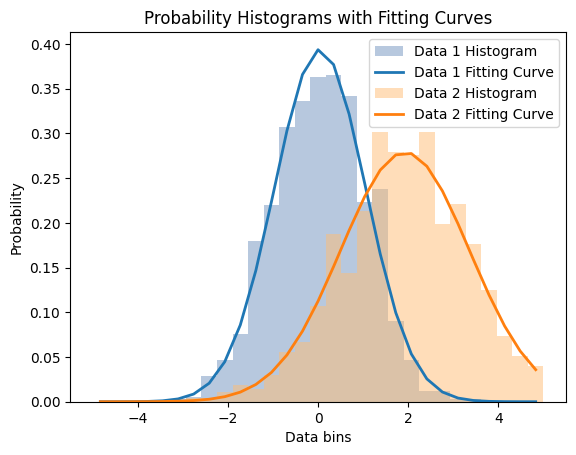

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 生成两组正态分布的随机数据
data1 = np.random.randn(1000)
data2 = np.random.randn(800) * 1.5 + 2  # 乘以一个标准差因子并加上一个均值偏移

# 计算两组数据的直方图和对应的密度函数
bins = np.linspace(-5, 5, 30)
hist1, bins1 = np.histogram(data1, bins=bins, density=True)
hist2, bins2 = np.histogram(data2, bins=bins, density=True)
bin_centers1 = (bins1[1:] + bins1[:-1]) / 2
bin_centers2 = (bins2[1:] + bins2[:-1]) / 2

# 拟合两组数据到正态分布并获取PDF值
pdf1 = norm.pdf(bin_centers1, *norm.fit(data1))
pdf2 = norm.pdf(bin_centers2, *norm.fit(data2))

# Plot 直方图和拟合曲线
plt.hist(data1, bins=bins, density=True, alpha=0.5, color='#7192be', label='Data 1 Histogram') # 冷色调蓝色
plt.plot(bin_centers1, pdf1, color='#1f77b4', linewidth=2, label='Data 1 Fitting Curve') # 更深的蓝色

plt.hist(data2, bins=bins, density=True, alpha=0.5, color='#ffbd74', label='Data 2 Histogram') # 暖色调橙色
plt.plot(bin_centers2, pdf2, color='#ff7f0e', linewidth=2, label='Data 2 Fitting Curve') # 更深的橙色

# 添加图例
plt.legend()

# 添加标题和标签
plt.title('Probability Histograms with Fitting Curves')
plt.xlabel('Data bins')
plt.ylabel('Probability')

# 展示图表
plt.show()


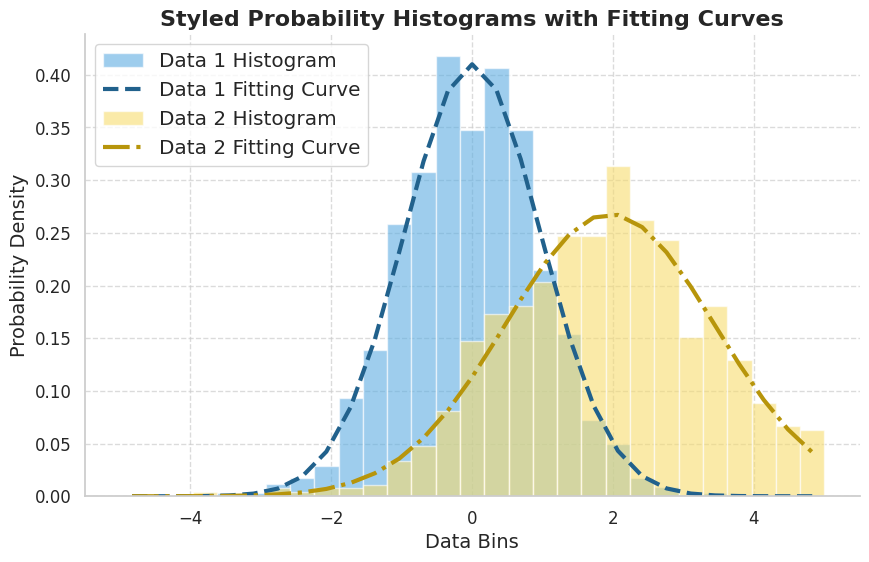

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

# 为图表设置 seaborn 样式
sns.set(style="whitegrid")

# 生成两组正态分布的随机数据
data1 = np.random.randn(1000)
data2 = np.random.randn(800) * 1.5 + 2

# 设置图表的字体大小
plt.rcParams['font.size'] = 12

# 计算两组数据的直方图和对应的密度函数
bins = np.linspace(-5, 5, 30)
hist1, bins1 = np.histogram(data1, bins=bins, density=True)
hist2, bins2 = np.histogram(data2, bins=bins, density=True)
bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# 拟合两组数据到正态分布并获取PDF值
pdf1 = norm.pdf(bin_centers1, *norm.fit(data1))
pdf2 = norm.pdf(bin_centers2, *norm.fit(data2))

# Plot 直方图和拟合曲线
plt.figure(figsize=(10, 6)) # 设置图表大小
plt.hist(data1, bins=bins, density=True, alpha=0.6, color='#5dade2', label='Data 1 Histogram')
plt.plot(bin_centers1, pdf1, color='#21618c', linestyle='--', linewidth=3, label='Data 1 Fitting Curve')

plt.hist(data2, bins=bins, density=True, alpha=0.6, color='#f7dc6f', label='Data 2 Histogram')
plt.plot(bin_centers2, pdf2, color='#b7950b', linestyle='-.', linewidth=3, label='Data 2 Fitting Curve')

# 添加图例，并指定大小
plt.legend(fontsize='large')

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和标签
plt.title('Styled Probability Histograms with Fitting Curves', fontsize=16, fontweight='bold')
plt.xlabel('Data Bins', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)

# 设置 ticker 的样式
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 移除上方和右侧的 spine
sns.despine()

# 展示图表
plt.show()

In [2]:
import csv

def find_min_row(csv_file, column_index):
    min_value = float('inf')
    min_row = None

    with open(csv_file, 'r') as file:
        reader = csv.reader(file)
        headers = next(reader)  # 跳过表头

        for row in reader:
            try:
                value = float(row[column_index])
                if value < min_value:
                    min_value = value
                    min_row = row
            except ValueError:
                pass  # 如果该列的值无法转换为浮点数，则跳过

    return min_row

# 示例用法
csv_file = '/mnt/disk1/xueying/JAEGER/models/training_data/Novartis_GNF_rm_error_5251_v3.csv'  # 替换为您的 CSV 文件路径
column_index = 3  # 替换为您要查找的列索引（从 0 开始）

min_row = find_min_row(csv_file, column_index)
if min_row:
    print("最小值所在的行：", min_row)
else:
    print("无法找到有效数据行")

最小值所在的行： ['GNF-Pf-1210', 'C[C@@H](O)[C@@H]1OCC[C@@H](C)[C@H](O)C(=O)OC[C@]23CCC(C)=C[C@H]2O[C@@H]4C[C@@H](OC(=O)C=CC=C1)[C@@]3(C)[C@@]45CO5', '', '0.000572']
